# Módulos

In [4]:
import pandas as pd
from itertools import combinations
from typing import List, Set, Tuple, Dict
from mlxtend.frequent_patterns import apriori, association_rules
import plotly.express as px
import plotly.io as pio
import kaleido

pio.renderers.default = 'iframe'
dataset = 'data_secretariado.csv'

# Implementación Propia de Aprori

## Código

In [5]:
class Apriori:
    """
    Implementación del algoritmo Apriori con caché de cálculos.
    """
    
    def __init__(self, soporte_min: float = 0.5, confianza_min: float = 0.5):
        """
        Inicializa el algoritmo Apriori optimizado.
        
        Parámetros:
        -----------
        soporte_min : float
            Umbral de soporte mínimo (0.0 a 1.0). Default: 0.5
        confianza_min : float
            Umbral de confianza mínimo (0.0 a 1.0). Default: 0.5
            
        Regresa:
        --------
        None
        """
        self.soporte_min = soporte_min
        self.confianza_min = confianza_min
        self.transacciones = []
        self.itemsets_frecuentes = {}
        self.reglas_asociacion = []
        
        # Caché de soportes
        self.cache_soporte = {}
        
        # Indexar transacciones
        self.num_transacciones = 0
    
    def carga_transacciones(self, datos: pd.DataFrame, columnas: List[str] = None) -> None:
        """
        Carga transacciones desde un DataFrame de pandas.
        
        Parámetros:
        -----------
        datos : pd.DataFrame
            DataFrame con los datos de transacciones
        columnas : List[str], optional
            Columnas a utilizar. Si es None, usa todas menos la primera (ID).
            
        Regresa:
        --------
        None
        """
        if columnas is None:
            columnas = datos.columns[1:]
        
        self.transacciones = []
        for idx, fila in datos.iterrows():
            transaccion = []
            for columna in columnas:
                if pd.notna(fila[columna]) and fila[columna] != "":
                    transaccion.append(f"{columna}={fila[columna]}")
            if transaccion:
                self.transacciones.append(frozenset(transaccion))
        
        # Guardar número de transacciones
        self.num_transacciones = len(self.transacciones)
        
        # Convertir a conjunto de conjuntos para búsqueda más rápida
        self.transacciones_set = [set(t) for t in self.transacciones]
        
        print(f"✓ {self.num_transacciones} transacciones cargadas")
    
    def calcula_soporte(self, itemset: frozenset) -> float:
        """
        Calcula el soporte de un itemset (con caché).
        
        Parámetros:
        -----------
        itemset : frozenset
            Conjunto de items para el cual calcular el soporte
            
        Regresa:
        --------
        float
            Valor de soporte entre 0.0 y 1.0
        """
        # Verificar caché primero
        if itemset in self.cache_soporte:
            return self.cache_soporte[itemset]
        
        # Contar transacciones que contienen el itemset
        contador = sum(1 for transaccion in self.transacciones_set 
                       if itemset.issubset(transaccion))
        soporte = contador / self.num_transacciones if self.num_transacciones > 0 else 0.0
        
        #Guardar en caché
        self.cache_soporte[itemset] = soporte
        
        return soporte
    
    def generar_candidatos(self, itemsets: List[frozenset], k: int) -> List[frozenset]:
        """
        Genera candidatos de forma más eficiente (F-k-join).
        
        Parámetros:
        -----------
        itemsets : List[frozenset]
            Lista de itemsets frecuentes del nivel anterior
        k : int
            Tamaño del itemset a generar
            
        Regresa:
        --------
        List[frozenset]
            Lista de candidatos generados
        """
        if k == 2:
            # Para k=2, simplemente hacer combinaciones de items
            items = set()
            for itemset in itemsets:
                items.update(itemset)
            items = sorted(list(items))
            candidatos = [frozenset([items[i], items[j]]) 
                         for i in range(len(items)) 
                         for j in range(i + 1, len(items))]
        else:
            # Para k>2, unir itemsets que comparten k-2 items
            candidatos = set()
            itemsets_sorted = sorted([sorted(list(x)) for x in itemsets])
            
            for i in range(len(itemsets_sorted)):
                for j in range(i + 1, len(itemsets_sorted)):
                    # Si comparten los primeros k-2 elementos
                    if itemsets_sorted[i][:-1] == itemsets_sorted[j][:-1]:
                        union = frozenset(itemsets_sorted[i]) | frozenset(itemsets_sorted[j])
                        if len(union) == k:
                            candidatos.add(union)
            
            candidatos = list(candidatos)
        
        return candidatos
    
    def obtiene_itemsets_frecuentes(self, itemsets: List[frozenset]) -> List[frozenset]:
        """
        Filtra itemsets por el umbral de soporte mínimo.
        
        Parámetros:
        -----------
        itemsets : List[frozenset]
            Lista de itemsets candidatos
            
        Regresa:
        --------
        List[frozenset]
            Lista de itemsets que cumplen con soporte_min
        """
        frecuentes = []
        for itemset in itemsets:
            if self.calcula_soporte(itemset) >= self.soporte_min:
                frecuentes.append(itemset)
        
        return frecuentes
    
    def apriori(self) -> Dict[int, List[Tuple[frozenset, float]]]:
        """
        Ejecuta el algoritmo Apriori completo (optimizado).
        
        Parámetros:
        -----------
        (ninguno)
        
        Regresa:
        --------
        Dict[int, List[Tuple[frozenset, float]]]
            Diccionario de itemsets frecuentes por nivel
        """
        if not self.transacciones:
            raise ValueError("No hay transacciones cargadas. Usa carga_transacciones() primero.")
        
        print(f"\n Ejecutando Apriori (soporte_min={self.soporte_min})...")
        
        self.itemsets_frecuentes = {}
        
        # Genera itemsets de tamaño 1
        print(" Generando itemsets de tamaño 1...")
        items = set()
        for transaccion in self.transacciones:
            items.update(transaccion)
        
        candidatos_1 = [frozenset([item]) for item in items]
        frecuentes_1 = self.obtiene_itemsets_frecuentes(candidatos_1)
        
        if not frecuentes_1:
            print(" ✗ No se encontraron itemsets frecuentes")
            return self.itemsets_frecuentes
        
        self.itemsets_frecuentes[1] = [(itemset, self.calcula_soporte(itemset)) 
                                        for itemset in frecuentes_1]
        
        print(f" ✓ {len(frecuentes_1)} itemsets de tamaño 1")
        
        # Genera itemsets de tamaño k > 1
        k = 2
        frecuentes_actuales = frecuentes_1
        
        while frecuentes_actuales:
            print(f" Generando itemsets de tamaño {k}...")
            
            candidatos_k = self.generar_candidatos(frecuentes_actuales, k)
            
            if not candidatos_k:
                break
            
            frecuentes_k = self.obtiene_itemsets_frecuentes(candidatos_k)
            
            if not frecuentes_k:
                print(f" ✓ {len(frecuentes_k)} itemsets de tamaño {k}")
                break
            
            self.itemsets_frecuentes[k] = [(itemset, self.calcula_soporte(itemset)) 
                                            for itemset in frecuentes_k]
            
            print(f" ✓ {len(frecuentes_k)} itemsets de tamaño {k}")
            
            frecuentes_actuales = frecuentes_k
            k += 1
        
        print(f"✓ Total de itemsets: {sum(len(v) for v in self.itemsets_frecuentes.values())}")
        
        return self.itemsets_frecuentes
    
    def calcula_confianza(self, antecedente: frozenset, consecuente: frozenset) -> float:
        """
        Calcula la confianza (con caché).
        
        Parámetros:
        -----------
        antecedente : frozenset
            Conjunto de items antecedentes
        consecuente : frozenset
            Conjunto de items consecuentes
            
        Regresa:
        --------
        float
            Valor de confianza entre 0.0 y 1.0
        """
        soporte_antecedente = self.calcula_soporte(antecedente)
        if soporte_antecedente == 0:
            return 0.0
        
        soporte_union = self.calcula_soporte(antecedente | consecuente)
        return soporte_union / soporte_antecedente
    
    def calcula_lift(self, antecedente: frozenset, consecuente: frozenset) -> float:
        """
        Calcula el lift (con caché).
        
        Parámetros:
        -----------
        antecedente : frozenset
            Conjunto de items antecedentes
        consecuente : frozenset
            Conjunto de items consecuentes
            
        Regresa:
        --------
        float
            Valor de lift
        """
        confianza = self.calcula_confianza(antecedente, consecuente)
        soporte_consecuente = self.calcula_soporte(consecuente)
        
        if soporte_consecuente == 0:
            return 0.0
        
        return confianza / soporte_consecuente
    
    def genera_reglas_asociacion(self) -> List[Dict]:
        """
        Genera reglas de asociación (optimizado).
        
        Parámetros:
        -----------
        (ninguno)
        
        Regresa:
        --------
        List[Dict]
            Lista de reglas de asociación
        """
        if not self.itemsets_frecuentes:
            raise ValueError("Primero debes ejecutar apriori()")
        
        print(f"\nGenerando reglas (confianza_min={self.confianza_min})...")
        
        self.reglas_asociacion = []
        contador_reglas = 0
        
        # Procesa itemsets de tamaño >= 2
        for k in sorted(self.itemsets_frecuentes.keys()):
            if k < 2:
                continue
            
            num_itemsets_k = len(self.itemsets_frecuentes[k])
            
            for idx, (itemset, soporte) in enumerate(self.itemsets_frecuentes[k]):
                if (idx + 1) % max(1, num_itemsets_k // 10) == 0:
                    print(f"  Procesando nivel {k}: {idx + 1}/{num_itemsets_k}")
                
                items = list(itemset)
                
                # Solo generar particiones, no todas las combinaciones
                for r in range(1, len(items)):
                    for items_antecedente in combinations(items, r):
                        antecedente = frozenset(items_antecedente)
                        consecuente = itemset - antecedente
                        
                        confianza = self.calcula_confianza(antecedente, consecuente)
                        
                        if confianza >= self.confianza_min:
                            lift = self.calcula_lift(antecedente, consecuente)
                            
                            self.reglas_asociacion.append({
                                'antecedente': antecedente,
                                'consecuente': consecuente,
                                'soporte': soporte,
                                'confianza': confianza,
                                'lift': lift
                            })
                            
                            contador_reglas += 1
        
        print(f"{contador_reglas} reglas generadas")
        
        return self.reglas_asociacion
    
    def obtiene_reglas_dataframe(self) -> pd.DataFrame:
        """
        Convierte las reglas generadas a un DataFrame de pandas.
        
        Parámetros:
        -----------
        (ninguno)
        
        Regresa:
        --------
        pd.DataFrame
            DataFrame con las reglas
        """
        if not self.reglas_asociacion:
            raise ValueError("Primero debes ejecutar genera_reglas_asociacion()")
        
        df = pd.DataFrame({
            'antecedente': [regla['antecedente'] for regla in self.reglas_asociacion],
            'consecuente': [regla['consecuente'] for regla in self.reglas_asociacion],
            'soporte': [regla['soporte'] for regla in self.reglas_asociacion],
            'confianza': [regla['confianza'] for regla in self.reglas_asociacion],
            'lift': [regla['lift'] for regla in self.reglas_asociacion]
        })
        
        return df.sort_values('lift', ascending=False).reset_index(drop=True)
    
    def obtiene_itemsets_frecuentes_dataframe(self) -> pd.DataFrame:
        """
        Convierte los itemsets frecuentes a un DataFrame de pandas.
        
        Parámetros:
        -----------
        (ninguno)
        
        Regresa:
        --------
        pd.DataFrame
            DataFrame con los itemsets
        """
        datos = []
        for k, lista_itemsets in sorted(self.itemsets_frecuentes.items()):
            for itemset, soporte in lista_itemsets:
                datos.append({
                    'itemset': itemset,
                    'soporte': soporte,
                    'tamaño': k
                })
        
        df = pd.DataFrame(datos)
        return df.sort_values('soporte', ascending=False).reset_index(drop=True)

## Limpieza del Dataset y Cálculos Preliminares

In [6]:
# Limpieza del dataset
datos = pd.read_csv(dataset)

# Convertir fechas a datetime
datos['FECHA_NACIMIENTO'] = pd.to_datetime(datos['FECHA_NACIMIENTO'], format='%Y-%m-%d', errors='coerce')
datos['FECHA_DESAPARICION'] = pd.to_datetime(datos['FECHA_DESAPARICION'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
datos['FECHA_REGISTRO'] = pd.to_datetime(datos['FECHA_REGISTRO'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Discretizar EDAD
datos['EDAD'] = (pd.Timestamp.now() - datos['FECHA_NACIMIENTO']).dt.days / 365.25
datos['GRUPO_EDAD'] = pd.cut(datos['EDAD'], bins=[0, 12, 18, 30, 50, 100], 
                              labels=['0-12', '13-17', '18-30', '31-50', '50+'])

# Discretizar FECHA_DESAPARICION
datos['MES_DESAPARICION'] = datos['FECHA_DESAPARICION'].dt.month
datos['AÑO_DESAPARICION'] = datos['FECHA_DESAPARICION'].dt.year

# Remover columnas originales (ya tenemos discretizadas)
columnas_a_remover = [
    'ID_VICTIMA',
    'CVE_ENT',
    'CVE_MUN',
    'FECHA_NACIMIENTO',
    'FECHA_DESAPARICION',
    'FECHA_REGISTRO',
]

datos_limpio = datos.drop(columns=columnas_a_remover, errors='ignore')
datos_limpio = datos_limpio[~(datos_limpio == 'CONFIDENCIAL').all(axis=1)]

print(f"\nForma: {datos_limpio.shape}")
print(f"Columnas: {list(datos_limpio.columns)}")

print("Distribución de Valores x Columna")
for columna in datos_limpio.columns:
    valores_unicos = datos_limpio[columna].nunique()
    print(f"\n{columna}:")
    print(f"   - Valores únicos: {valores_unicos}")
    print(f"   - Top 5 valores más frecuentes:")
    print(datos_limpio[columna].value_counts().head(5))

print("Cálculo de Soporte Individual (Items de tamaño 1)")
soportes_items = {}

for columna in datos_limpio.columns:
    valores_unicos = datos_limpio[columna].dropna().unique()
    
    for valor in valores_unicos:
        if valor != 'CONFIDENCIAL':
            item = f"{columna}={valor}"
            num_ocurrencias = (datos_limpio[columna] == valor).sum()
            soporte = num_ocurrencias / len(datos_limpio)
            soportes_items[item] = soporte

print("\nItems con mayor soporte")
items_ordenados = sorted(soportes_items.items(), key=lambda x: x[1], reverse=True)
for item, soporte in items_ordenados[:20]:
    print(f" {item}: {soporte:.4f}")

# Contar cuántos items tienen soporte >= X
for threshold in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    count = sum(1 for s in soportes_items.values() if s >= threshold)
    print(f"Items con soporte >= {threshold}: {count}")



Forma: (133887, 9)
Columnas: ['ORIGEN_REPORTE', 'SEXO', 'ESTATUS_VICTIMA', 'ENTIDAD', 'MUNICIPIO', 'EDAD', 'GRUPO_EDAD', 'MES_DESAPARICION', 'AÑO_DESAPARICION']
Distribución de Valores x Columna

ORIGEN_REPORTE:
   - Valores únicos: 74
   - Top 5 valores más frecuentes:
ORIGEN_REPORTE
PROCURADURIA GENERAL DE JUSTICIA DEL ESTADO DE TAMAULIPAS      12085
FISCALIA GENERAL DE JALISCO                                    10323
PORTAL                                                          8659
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE MEXICO     7286
PROCURADURIA GENERAL DE JUSTICIA DEL ESTADO DE MICHOACAN        5892
Name: count, dtype: int64

SEXO:
   - Valores únicos: 4
   - Top 5 valores más frecuentes:
SEXO
HOMBRE           64666
CONFIDENCIAL     49149
MUJER            19716
INDETERMINADO      356
Name: count, dtype: int64

ESTATUS_VICTIMA:
   - Valores únicos: 3
   - Top 5 valores más frecuentes:
ESTATUS_VICTIMA
DESAPARECIDA     79881
CONFIDENCIAL     49149
NO LOCALIZADA   

## Ejecución y Obtención de Reglas de Asosiación

In [7]:
# el valor de 0.05 es por los resultados anteriores.
apriori_manual = Apriori(soporte_min=0.05, confianza_min=0.3)
apriori_manual.carga_transacciones(datos_limpio, columnas=datos_limpio.columns)
itemsets_manual = apriori_manual.apriori()
# df_itemsets_manual = apriori_manual.obtiene_itemsets_frecuentes_dataframe()
reglas_asociación = apriori_manual.genera_reglas_asociacion()
df_reglas_manual = apriori_manual.obtiene_reglas_dataframe()

df_reglas_manual.to_csv('datos_apriori_manual.csv', encoding='utf-8')

✓ 133887 transacciones cargadas

 Ejecutando Apriori (soporte_min=0.05)...
 Generando itemsets de tamaño 1...
 ✓ 27 itemsets de tamaño 1
 Generando itemsets de tamaño 2...
 ✓ 22 itemsets de tamaño 2
 Generando itemsets de tamaño 3...
 ✓ 8 itemsets de tamaño 3
 Generando itemsets de tamaño 4...
 ✓ 1 itemsets de tamaño 4
 Generando itemsets de tamaño 5...
✓ Total de itemsets: 58

Generando reglas (confianza_min=0.3)...
  Procesando nivel 2: 2/22
  Procesando nivel 2: 4/22
  Procesando nivel 2: 6/22
  Procesando nivel 2: 8/22
  Procesando nivel 2: 10/22
  Procesando nivel 2: 12/22
  Procesando nivel 2: 14/22
  Procesando nivel 2: 16/22
  Procesando nivel 2: 18/22
  Procesando nivel 2: 20/22
  Procesando nivel 2: 22/22
  Procesando nivel 3: 1/8
  Procesando nivel 3: 2/8
  Procesando nivel 3: 3/8
  Procesando nivel 3: 4/8
  Procesando nivel 3: 5/8
  Procesando nivel 3: 6/8
  Procesando nivel 3: 7/8
  Procesando nivel 3: 8/8
  Procesando nivel 4: 1/1
69 reglas generadas


## Scatter Plots para visualización de reglas

In [8]:
df_apriori_manual = pd.read_csv('datos_apriori_manual.csv')

df_apriori_manual['antecedente'] = df_apriori_manual['antecedente'].str.extract(r"{(?:'|\")(.*)(?:'|\")}")
df_apriori_manual['consecuente'] = df_apriori_manual['consecuente'].str.extract(r"{(?:'|\")(.*)(?:'|\")}")
df_filtrado_manual = df_apriori_manual[df_apriori_manual['lift'] < 5]

fig_apriori = px.scatter(
    df_filtrado_manual,
    x='confianza',
    y='lift',
    size='soporte',
    hover_name='antecedente',
    hover_data={'consecuente': True,
                'soporte': True,
                'confianza': True,
                'lift': True},

    labels={'confianza': 'Confianza',
            'lift': 'Lift',
            'soporte': 'Suporte'}
)

fig_apriori.update_layout(
    title_text=f'Reglas de Asociación Lift (Implementación Manual) <= 5 ({len(df_filtrado_manual)} reglas)',
    title_x=0.5
)

fig_apriori.write_image('grafico_apriori_reglas_manual.png')
fig_apriori.show()

Resorting to unclean kill browser.


In [9]:
df_manual_final = df_filtrado_manual[['antecedente', 'consecuente', 'soporte', 'confianza', 'lift']]
df_manual_final.to_csv('datos_manual_final.csv', encoding='utf-8')
df_manual_final

,antecedente,consecuente,soporte,confianza,lift
10,"ENTIDAD=JALISCO', 'SEXO=CONFIDENCIAL",ESTATUS_VICTIMA=CONFIDENCIAL,0.074690,1.000000,2.724104
11,"ENTIDAD=JALISCO', 'MUNICIPIO=CONFIDENCIAL', 'E...",SEXO=CONFIDENCIAL,0.074690,1.000000,2.724104
12,"ENTIDAD=JALISCO', 'ESTATUS_VICTIMA=CONFIDENCIAL",SEXO=CONFIDENCIAL,0.074690,1.000000,2.724104
13,SEXO=CONFIDENCIAL,"MUNICIPIO=CONFIDENCIAL', 'ESTATUS_VICTIMA=CONF...",0.367093,1.000000,2.724104
14,SEXO=CONFIDENCIAL,MUNICIPIO=CONFIDENCIAL,0.367093,1.000000,2.724104
15,"ENTIDAD=JALISCO', 'MUNICIPIO=CONFIDENCIAL",ESTATUS_VICTIMA=CONFIDENCIAL,0.074690,1.000000,2.724104
16,MUNICIPIO=CONFIDENCIAL,SEXO=CONFIDENCIAL,0.367093,1.000000,2.724104
17,ESTATUS_VICTIMA=CONFIDENCIAL,SEXO=CONFIDENCIAL,0.367093,1.000000,2.724104
18,SEXO=CONFIDENCIAL,ESTATUS_VICTIMA=CONFIDENCIAL,0.367093,1.000000,2.724104
19,ESTATUS_VICTIMA=CONFIDENCIAL,MUNICIPIO=CONFIDENCIAL,0.367093,1.000000,2.724104


# Uso de mlxtend

## Ejecución

In [10]:
# Para trabajar con algo que entienda el apriori de mlxtend, se debe convertir a un dataframe booleano/onehot.
# Esto es, convertir cada valor en una columna booleana.

datos_para_mlxtend = datos_limpio.copy()

# En lugar de insertar columna por columna, crear una lista de columnas
columnas_onehot = {}

for columna in datos_para_mlxtend.columns:
    valores_unicos = datos_para_mlxtend[columna].dropna().unique()
    
    for valor in valores_unicos:
        nombre_col = f"{columna}={valor}"
        columnas_onehot[nombre_col] = (datos_para_mlxtend[columna] == valor).astype(bool)

datos_onehot = pd.DataFrame(columnas_onehot)

itemsets_frequentes_mlxtend = apriori(datos_onehot, min_support=0.05, use_colnames=True)
reglas_mlxtend = association_rules(itemsets_frequentes_mlxtend, metric='confidence', min_threshold=0.3)
reglas_mlxtend = reglas_mlxtend[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
reglas_mlxtend.to_csv('datos_mlxtend.csv', encoding='utf-8')

## Scatter Plot de Lift de Reglas

In [11]:
df_mlxtend = pd.read_csv('datos_mlxtend.csv')

df_mlxtend['antecedents'] = df_mlxtend['antecedents'].str.extract(r"{(?:'|\")(.*)(?:'|\")}")
df_mlxtend['consequents'] = df_mlxtend['consequents'].str.extract(r"{(?:'|\")(.*)(?:'|\")}")
df_filtrado_mlxtend = df_mlxtend[df_mlxtend['lift'] < 5]

fig_mlxtend = px.scatter(
    df_filtrado_mlxtend,
    x='confidence',
    y='lift',
    size='support',
    hover_name='antecedents',
    hover_data={'consequents': True,
                'support': True,
                'confidence': True,
                'lift': True},
    labels={'confidence': 'Confianza',
            'lift': 'Lift',
            'support': 'Soporte'}
)

fig_mlxtend.update_layout(
    title_text=f'Reglas de Asociación (mlxtend) Lift <= 5 ({len(df_filtrado_mlxtend)} reglas)',
    title_x=0.5
)

fig_mlxtend.write_image('grafico_apriori_reglas_mlxtend.png')
fig_mlxtend.show()

## Tabla de Reglas

In [12]:
df_mlxtend_final = df_filtrado_mlxtend[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
df_mlxtend_final.to_csv('datos_mlxtend_final.csv', encoding='utf-8')
df_mlxtend_final

,antecedents,consequents,support,confidence,lift
0,ORIGEN_REPORTE=PROCURADURIA GENERAL DE JUSTICI...,ESTATUS_VICTIMA=DESAPARECIDA,0.054300,0.601572,1.008284
7,SEXO=CONFIDENCIAL,ESTATUS_VICTIMA=CONFIDENCIAL,0.367093,1.000000,2.724104
8,ESTATUS_VICTIMA=CONFIDENCIAL,SEXO=CONFIDENCIAL,0.367093,1.000000,2.724104
9,ENTIDAD=JALISCO,SEXO=CONFIDENCIAL,0.074690,0.675174,1.839244
10,SEXO=CONFIDENCIAL,MUNICIPIO=CONFIDENCIAL,0.367093,1.000000,2.724104
11,MUNICIPIO=CONFIDENCIAL,SEXO=CONFIDENCIAL,0.367093,1.000000,2.724104
12,SEXO=HOMBRE,ESTATUS_VICTIMA=DESAPARECIDA,0.454189,0.940371,1.576137
13,ESTATUS_VICTIMA=DESAPARECIDA,SEXO=HOMBRE,0.454189,0.761257,1.576137
14,GRUPO_EDAD=50+,SEXO=HOMBRE,0.079067,0.875600,1.812876
15,SEXO=HOMBRE,GRUPO_EDAD=31-50,0.167126,0.346024,1.724608


## ALGORITMOS DE CLASIFICACIÓN

Objetivos:
* Construir un modelo de clasificación supervisada
* Realizar una partición train/test
* Evaluar el modelo usando métricas adecuadas
* Análizar variables relevantes y posibles sesgos
* Explicar la relación de las métricas con un escenario del mundo real

In [13]:
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Modelos
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Configuración visual
plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [14]:
# Carga del dataset
df = pd.read_csv("data_secretariado.csv")

# Muestra dimensiones
print("Dimensiones del dataset: ")
print(df.shape)

# Para visualizar las primeras filas
df.head()

Dimensiones del dataset: 
(133887, 11)


,ID_VICTIMA,ORIGEN_REPORTE,FECHA_NACIMIENTO,SEXO,FECHA_DESAPARICION,FECHA_REGISTRO,ESTATUS_VICTIMA,CVE_ENT,ENTIDAD,CVE_MUN,MUNICIPIO
0,D49C001E-41E4-45B7-B8FD-D867578F093E,FISCALIA GENERAL DE DURANGO,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,10,DURANGO,999,CONFIDENCIAL
1,2D2B5CD4-7AF7-48C3-887E-72F4C6403863,COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL EST...,1971-06-13,HOMBRE,2025-09-28 04:40:00,2025-09-29 10:00:00,DESAPARECIDA,25,SINALOA,4,CONCORDIA
2,6AE9098C-0C30-4709-9A2C-37F6312CD43E,PROCURADURIA GENERAL DE JUSTICIA DE LA CIUDAD ...,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,9,CIUDAD DE MÉXICO,999,CONFIDENCIAL
3,6B899D2D-F33D-4880-82CD-953FF972B9C3,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,2,BAJA CALIFORNIA,999,CONFIDENCIAL
4,3F026638-8169-4CEA-9D9A-E345B6D2D7B6,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,2,BAJA CALIFORNIA,999,CONFIDENCIAL


## Exploración inicial

<class 'pandas.DataFrame'>
RangeIndex: 133887 entries, 0 to 133886
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID_VICTIMA          133887 non-null  str  
 1   ORIGEN_REPORTE      133887 non-null  str  
 2   FECHA_NACIMIENTO    105000 non-null  str  
 3   SEXO                133887 non-null  str  
 4   FECHA_DESAPARICION  125727 non-null  str  
 5   FECHA_REGISTRO      127790 non-null  str  
 6   ESTATUS_VICTIMA     133887 non-null  str  
 7   CVE_ENT             133887 non-null  int64
 8   ENTIDAD             133887 non-null  str  
 9   CVE_MUN             133887 non-null  int64
 10  MUNICIPIO           133887 non-null  str  
dtypes: int64(2), str(9)
memory usage: 11.2 MB


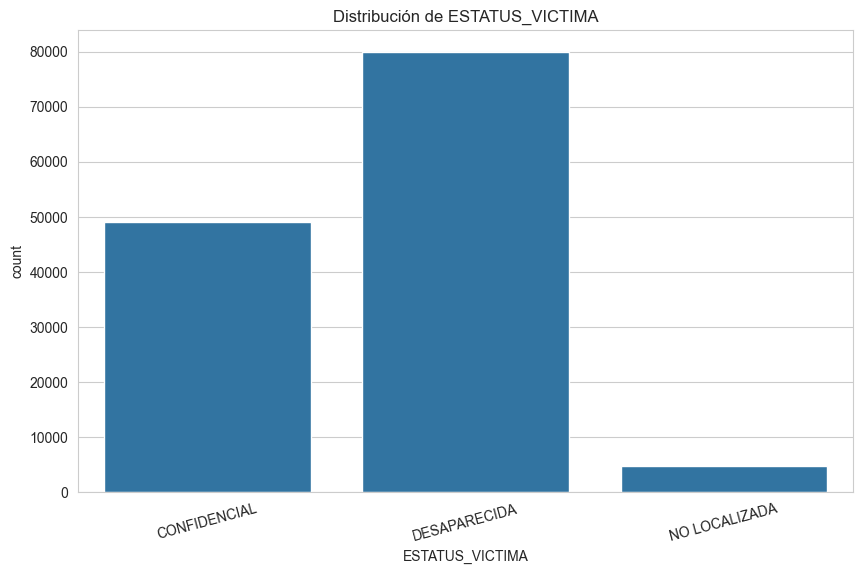

In [16]:
# Información general
df.info()

# Distribución de la variable objetivo
df["ESTATUS_VICTIMA"].value_counts()

# Visualización de la variable objetivo
sns.countplot(data=df, x = "ESTATUS_VICTIMA")
plt.title("Distribución de ESTATUS_VICTIMA")
plt.xticks(rotation=15)
plt.show()

## Observaciones iniciales

La variable objetivo presenta un desbalance ya que la clase DESAPARECIDA tiene una cantidad mucho mayor de registros a comparación de la clase NO LOCALIZADA y aún más a comparación de la clase NO LOCALIZADA.

Este desvalance puede provocar que un modelo obtenga un accuracy alto simplemente prediciendo la clase mayoritaria. Por ello se deben utilizar métricas adicionales como:

* Precisión
* Recall
* F1-score

## Limpieza del dataset

In [17]:
# Eliminando la columna de los id porque no nos va a servir para la predicción
df = df.drop(columns=["ID_VICTIMA"])

#Revisar datos faltantes
df.isnull().sum()

# Rellenar valores faltantes
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].median())

# verificamos de nuevo
df.isnull().sum().sum()

# separar variables predictoras y objetivo
X = df.drop(columns=["ESTATUS_VICTIMA"])
y = df["ESTATUS_VICTIMA"]

#Codificación de variables categoricas
label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

#Codificar variable objetivo
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Clases objetivo:")
for i, clase in enumerate(target_encoder.classes_):
    print(i, "->", clase)

C:\Users\yoba7\AppData\Local\Temp\ipykernel_27996\363598035.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


Clases objetivo:
0 -> CONFIDENCIAL
1 -> DESAPARECIDA
2 -> NO LOCALIZADA


## División de conjunto de entremaniento y prueba

In [19]:
# División train/test usando muestreo estratificado

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size = 0.20,
    random_state = 42,
    stratify = y_encoded
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (107109, 9)
Prueba: (26778, 9)


En esta división se empleó un porcentaje de:

* 80% entrenamiento
* 20% prueba

Ademas de que se usa stratify = y_encoded para conservar la proporción de clases en ambos  conjuntos, lo cual es importante debido al desbalance del set.

## Entrenamiento del modelo

In [20]:
# crear modelo

modelo = RandomForestClassifier(n_estimators=100,
                               random_state=42,
                               class_weight="balanced")

# Entrenamiento
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

## Evaluación del modelo

Accuracy : 0.9735
Precision : 0.9709
Recall : 0.9735
F1-score : 0.9718
               precision    recall  f1-score   support

 CONFIDENCIAL       1.00      1.00      1.00      9830
 DESAPARECIDA       0.97      0.99      0.98     15977
NO LOCALIZADA       0.68      0.51      0.58       971

     accuracy                           0.97     26778
    macro avg       0.88      0.83      0.85     26778
 weighted avg       0.97      0.97      0.97     26778



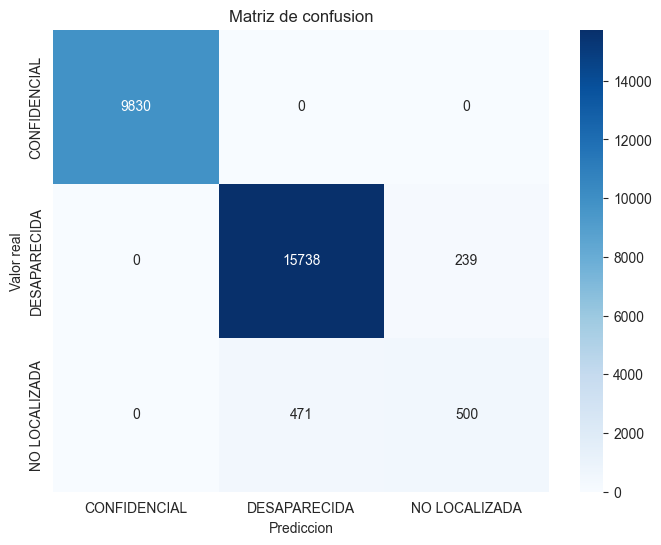

In [22]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precisión
precision = precision_score(y_test, y_pred, average="weighted")

# Recall
recall = recall_score(y_test, y_pred, average="weighted")

# F1-score
f1 = f1_score(y_test, y_pred, average = "weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Reporte completo de clasificación
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Matriz de confusion")
plt.show()

## Interpretación de métricas

## Accuracy
Mide el porcentaje total de predicciones correctas.
Se usa porque permite conocer el desempeño general del modelo y es fácil de interpretar. Su desventaja es que puede llegar a ser engañoso en casos de datasets desbalanceados.

## Precision
Mide qué tan confiables son las predicciones positivas.
Esto puede ayudar a reducir falsas alarmas

## Recall
Mide cuántos casos reales logra detectar el modelo.
Es importante identificar correctamente la mayor cantidad posible de casos reales. Si este valor fuera bajo podría significar que algunos casos relevantes no son detectados

## F1-score
Balancea precision y recall.
Este se eligió porque el dataset tiene clases desvalanceadas y equilibra la detección correcta de casos y evita falsas clasificaciones.

## Importancia de variables

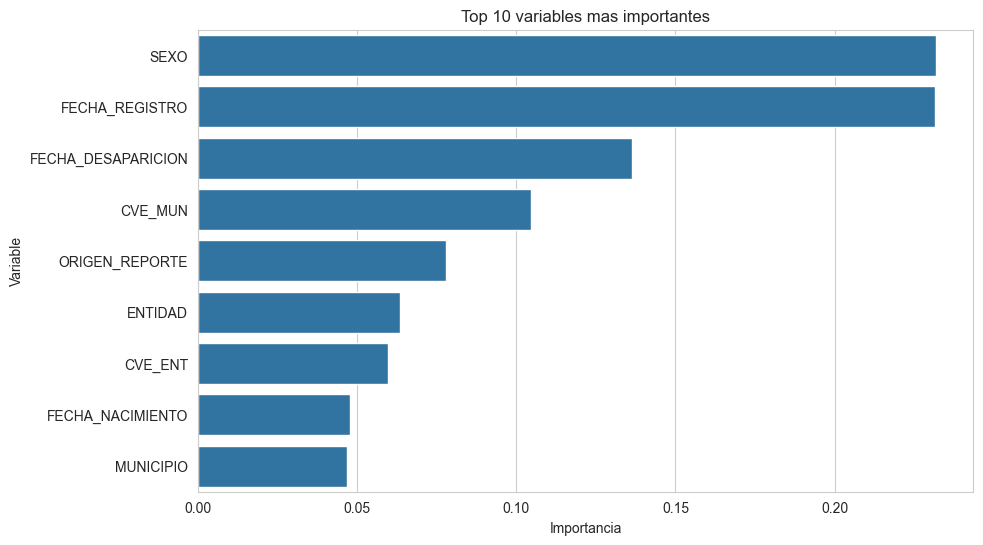

In [27]:
# Obtener importancia de variables
importancias = pd.DataFrame({"Variable" : X.columns,
                           "Importancia" : modelo.feature_importances_})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(10)

# Visualizar variables más importantes
top_importancias = importancias.head(10)

sns.barplot(data=top_importancias, x="Importancia", y="Variable")

plt.title("Top 10 variables mas importantes")
plt.show()

## Analisis de variables relevantes y posibles sesgos

Las variables más importantes representan la información que el modelo utiliza con mayor frecuencia para realizar predicciones.

Posibles observaciones:

* La entidad federativa puede influir debido a diferencias regionales en los reportes
* El sexo puede introducir sesgos sociales o de registro
* Las fechas puede reflejar cambios administrativos o patrones temporales

## Posbles sesgos del dataset

1. Registros confidenciales: Muchos datos contienen el valor CONFIDENCIAL, lo que reduce la calidad de la información disponible
2. Desbalance de clases: Existen muchas observaciones de una clase de que otras, lo que podría llevar a que el modelo favorezca a clases mayoritarias
3. Calidad de datos: Hay fechas faltantes y datos incompletos que pueden afectar el rendimiento
4. Sesgo institucional: Diferentes entidades podrían registrar información de forma distinta (Jalisco)

## CONCLUSIONES

Se construyó un modelo de clasificación supervisada para predecir ESTATUS_VICTIMA

## Aspectos implementados
* División train/test
* Muestreo estratificado
* Random Forest Classifier
* Evaluación con multiples métricas
* Análisis de importancia de variables

## Metricas seleccionadas

Se usaron:

* Accuracy
* Precision
* Recall
* F1-score

La elección se relaciona con escenarios donde:

* Detectar correctamente casos importantes es prioridad
* Es necesario reducir falsas clasificaciones

## Resultado general
El modelo logra identificar patrones dentro del dataset, aunque:

* El desbalance de las clases
* Los datos confidenciales
* Posibles sesgos institucionales

Pueden afectar el desempeño final.